In [44]:
# Importing the required packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr,spearmanr,kruskal
import sys
!{sys.executable} -m pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# loading the data into a dataframe

df = pd.read_csv('insurance.csv')

df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [8]:
# checking data shape
df.shape

(986, 11)

986 rows and 11 columns

In [9]:
# checking data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


In [10]:
# checking null enteries in the dataframe

df_null = df.isnull().sum()

df_null

Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
dtype: int64

No nulls in the 11 columns

## Univarient Analysis

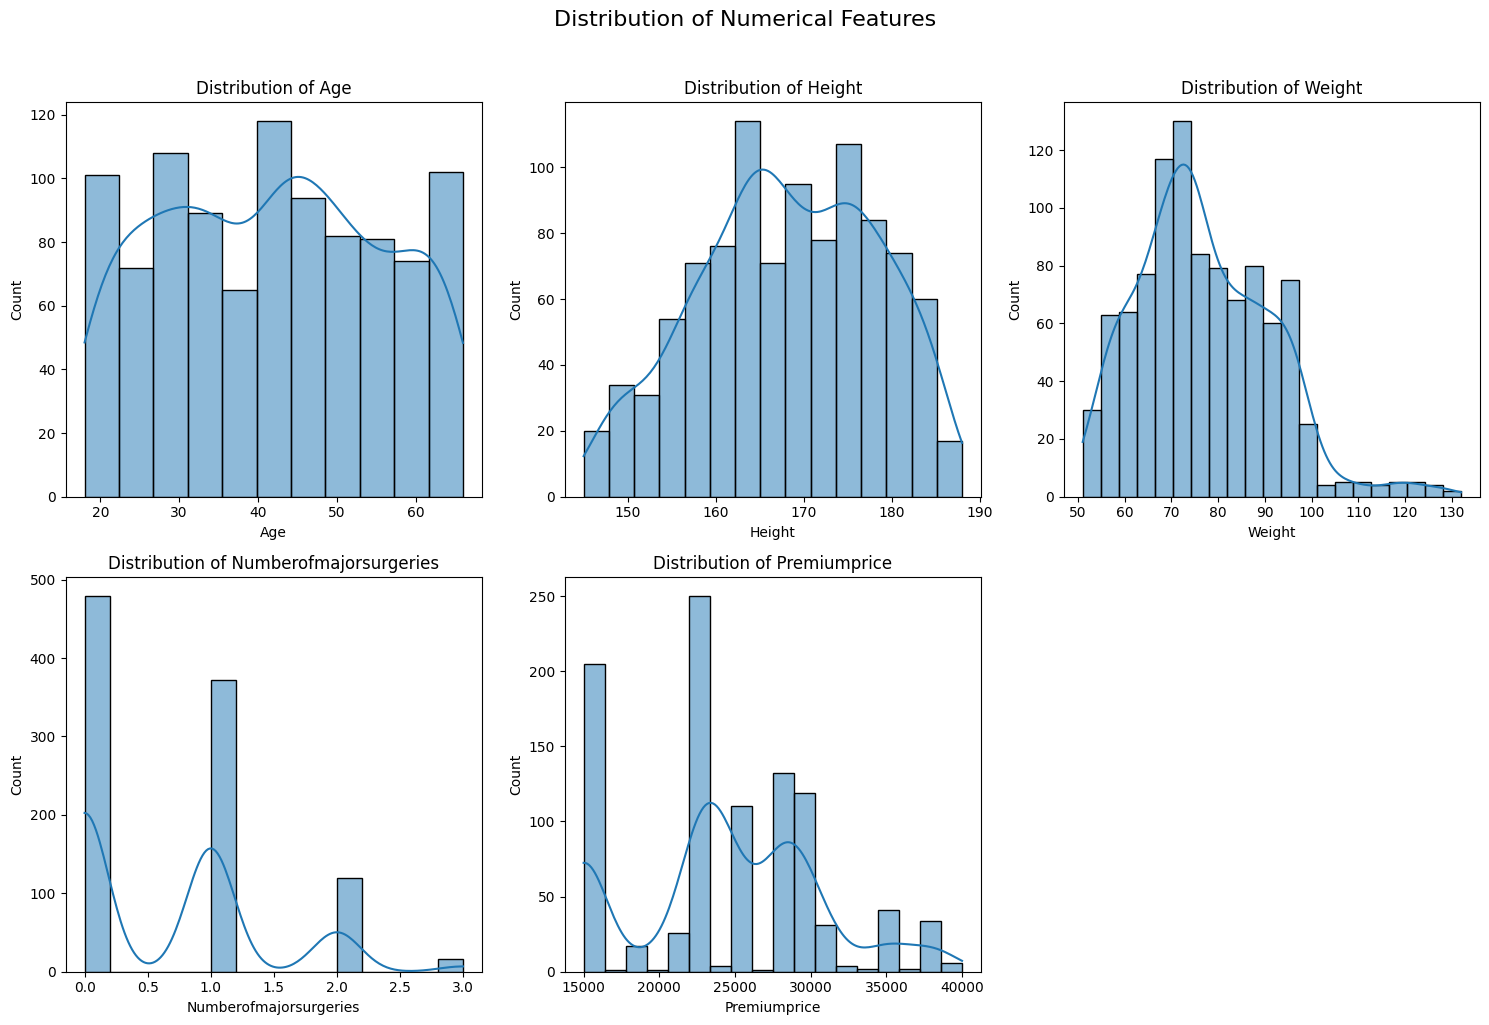

In [11]:
# checking distribution of the data 
fig,axes = plt.subplots(2,3,figsize = (15,10))
fig.suptitle('Distribution of Numerical Features',fontsize = 16,y =1.02)


axes = axes.flatten()

numerical_cols = ['Age','Height','Weight','NumberOfMajorSurgeries','PremiumPrice']

for idx,col in enumerate(numerical_cols):
    sns.histplot(data=df,x=col,kde=True,ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col.title()}')
    axes[idx].set_xlabel(col.title())
    axes[idx].set_ylabel('Count')


for idx in range(len(numerical_cols),len(axes)):

    fig.delaxes(axes[idx])


plt.tight_layout()
plt.show()






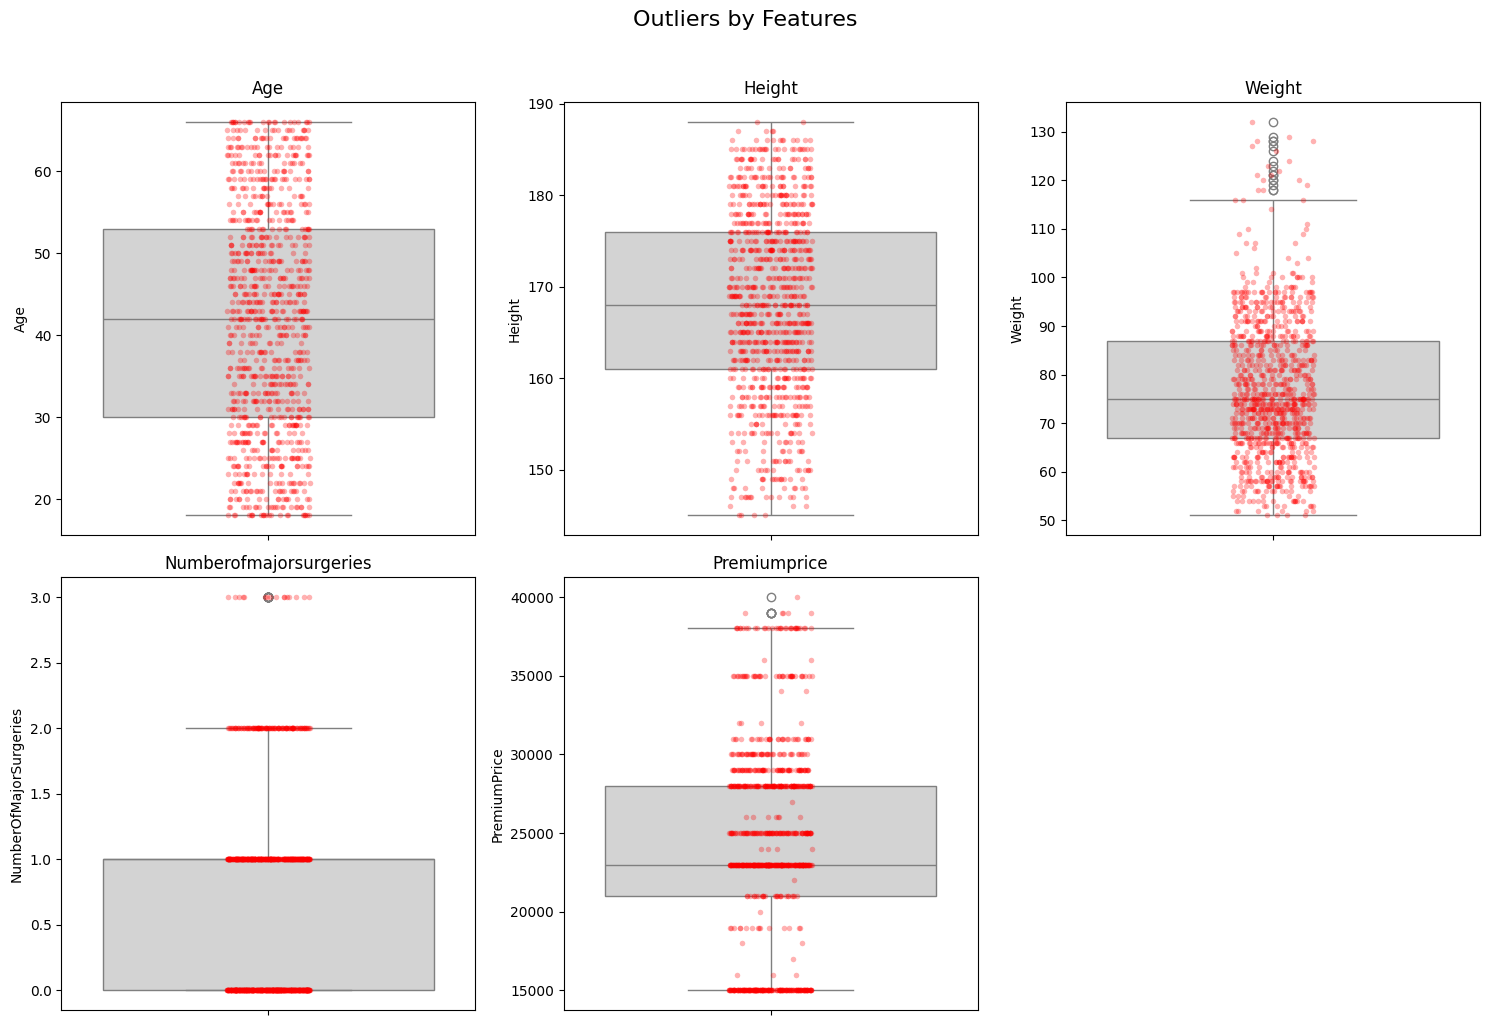

In [12]:
fig,axes = plt.subplots(2,3,figsize = (15,10))
fig.suptitle(f'Outliers by Features',fontsize = 16,y=1.02)

axes = axes.flatten()

for idx,col in enumerate(numerical_cols):
    
    sns.boxplot(y = df[col],ax=axes[idx],color ='lightgray')

    sns.stripplot(y = df[col],ax=axes[idx],color ='red',alpha=0.3,size=4)

    axes[idx].set_title(f"{col.title()}")


for idx in range(len(numerical_cols),len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


In [14]:
df.head(2)

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000


C:\Users\dev\AppData\Local\Temp\ipykernel_23052\1747142215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes',data= df ,palette= 'Set2')


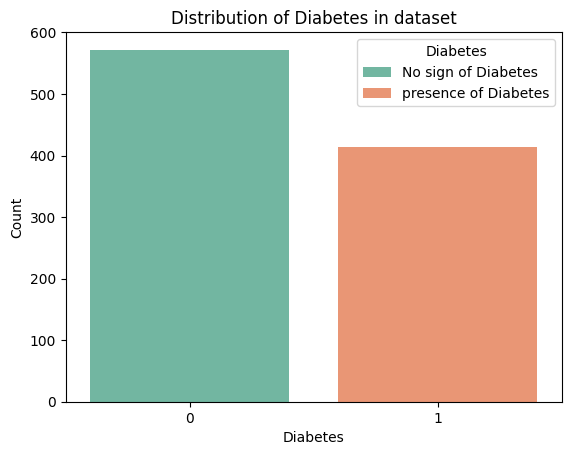

In [15]:
#count plot for Diabetes,BloodPresuureProblems,AnyTransplants,AnyChronicDiseases,KnownAllergies,HisotryofCancerInFamily

sns.countplot(x='Diabetes',data= df ,palette= 'Set2')

new_labels = ["No sign of Diabetes","presence of Diabetes"]


plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.legend(title= 'Diabetes',labels = new_labels )

plt.title("Distribution of Diabetes in dataset")

plt.show()

C:\Users\dev\AppData\Local\Temp\ipykernel_23052\10148148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df,ax=axes[i],palette='Set2')
C:\Users\dev\AppData\Local\Temp\ipykernel_23052\10148148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df,ax=axes[i],palette='Set2')
C:\Users\dev\AppData\Local\Temp\ipykernel_23052\10148148.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col,data=df,ax=axes[i],palette='Set2')
C:\Users\dev\AppData\Local\Temp\ipykernel_23052\10148148.py:11: FutureWarning: 

Passing

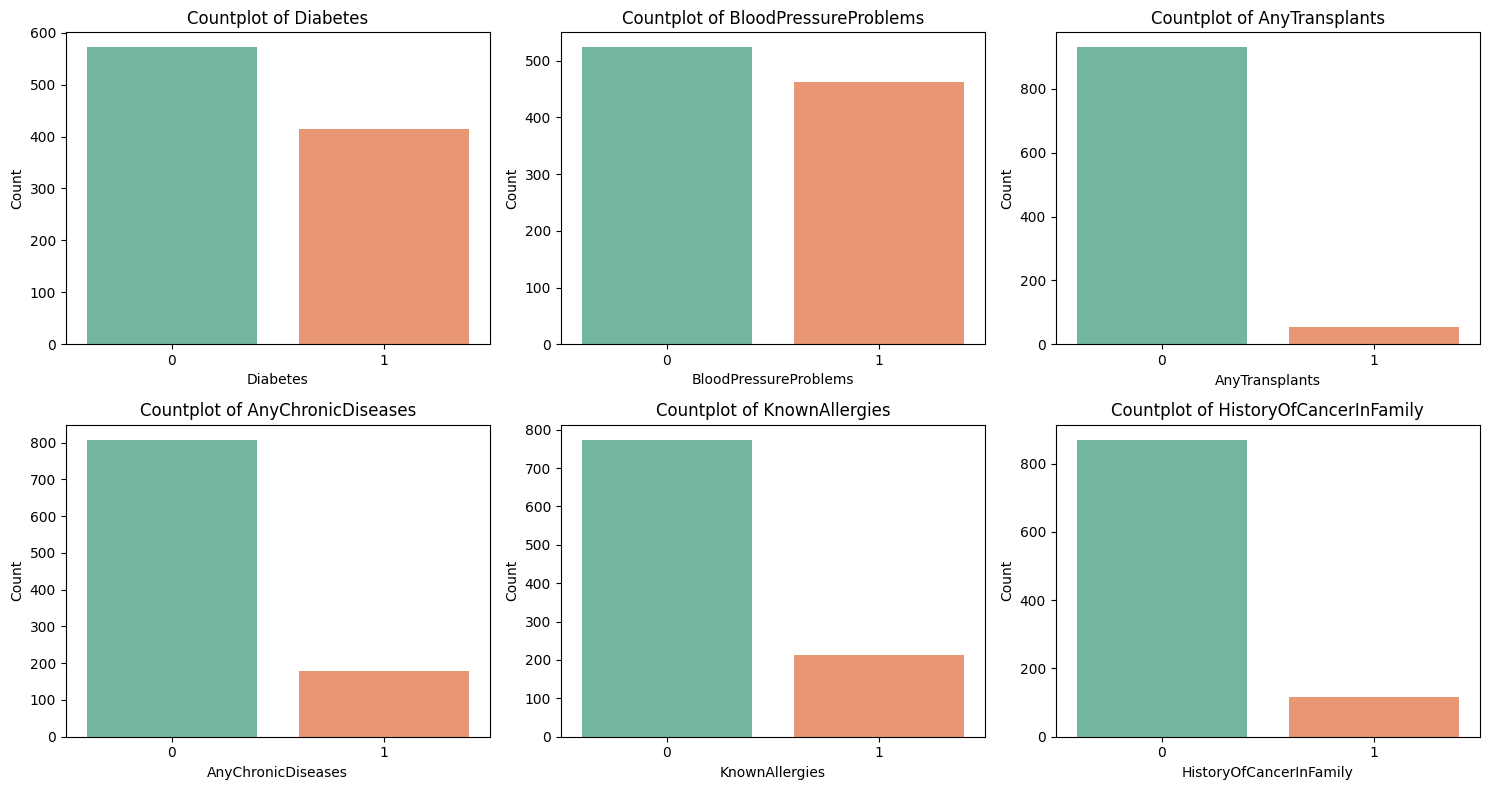

In [16]:

cols = ["Diabetes","BloodPressureProblems","AnyTransplants","AnyChronicDiseases","KnownAllergies","HistoryOfCancerInFamily"]


fig,axes = plt.subplots(nrows=2,ncols=3,figsize = (15,8))

axes = axes.flatten()


for i,col in enumerate(cols):

    sns.countplot(x=col,data=df,ax=axes[i],palette='Set2')

    axes[i].set_title(f"Countplot of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")


plt.tight_layout()
plt.show()

## Multi Varient Analysis

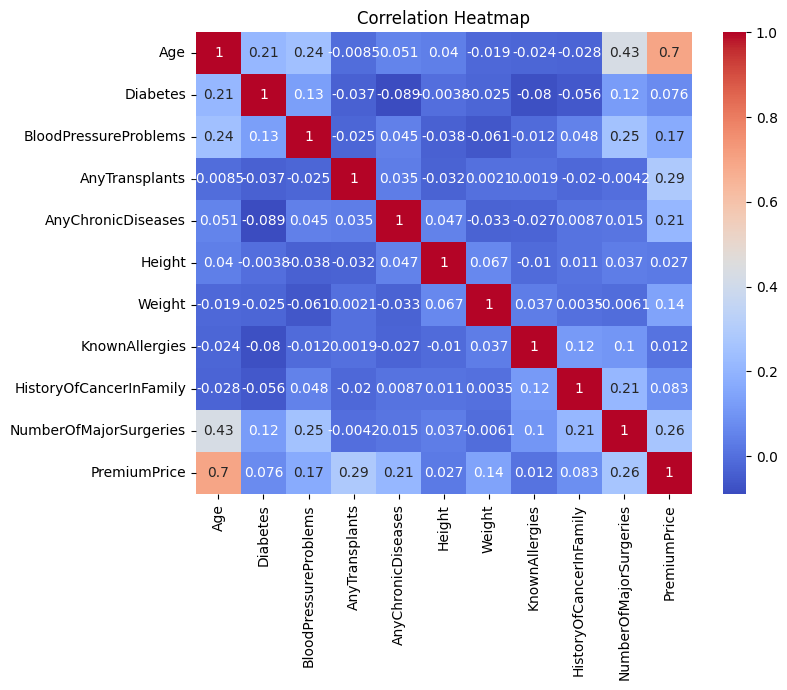

In [17]:
# correlation plot 

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr,annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [18]:
#IQR method for outlier treatment

#capped the outliers instead of removing as the data set is small 

df_capped = df.copy()

cols = ["Age","Height","Weight","PremiumPrice","NumberOfMajorSurgeries"]




for col in cols:

    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)

    IQR = Q3-Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df_capped[col] = np.where(df_capped[col] < lower_bound , lower_bound,
                       np.where(df_capped[col] > upper_bound,upper_bound,df_capped[col]) )
    

    print(f"{col}: Capped values below {lower_bound} to {upper_bound} above ")

    






   


   

Age: Capped values below -4.5 to 87.5 above 
Height: Capped values below 138.5 to 198.5 above 
Weight: Capped values below 37.0 to 117.0 above 
PremiumPrice: Capped values below 10500.0 to 38500.0 above 
NumberOfMajorSurgeries: Capped values below -1.5 to 2.5 above 


## Feature Engineering

In [19]:
# BMI (Body Mass Index)


df_capped["BMI"] = df_capped['Weight']/ ((df_capped['Height']/100)) **2

df_capped["BMI_Category"] = pd.cut(df_capped['BMI'],bins=[0,18.5,25,30,100],labels=['Underweight','Normal','Overweight','Obese'])


df_capped.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,BMI_Category
0,45.0,0,0,0,0,155.0,57.0,0,0,0.0,25000.0,23.725286,Normal
1,60.0,1,0,0,0,180.0,73.0,0,0,0.0,29000.0,22.530864,Normal
2,36.0,1,1,0,0,158.0,59.0,0,0,1.0,23000.0,23.634033,Normal
3,52.0,1,1,0,1,183.0,93.0,0,0,2.0,28000.0,27.770313,Overweight
4,38.0,0,0,0,1,166.0,88.0,0,0,1.0,23000.0,31.934969,Obese


In [20]:
# Health Risk Score

df_capped['Health_Risk_Score'] = (
    df_capped['Diabetes'] + 
    df_capped['BloodPressureProblems'] + 
    df_capped['AnyTransplants'] + 
    df_capped['AnyChronicDiseases'] + 
    df_capped['KnownAllergies'] + 
    df_capped['HistoryOfCancerInFamily']
)

df_capped.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,BMI_Category,Health_Risk_Score
0,45.0,0,0,0,0,155.0,57.0,0,0,0.0,25000.0,23.725286,Normal,0
1,60.0,1,0,0,0,180.0,73.0,0,0,0.0,29000.0,22.530864,Normal,1
2,36.0,1,1,0,0,158.0,59.0,0,0,1.0,23000.0,23.634033,Normal,2
3,52.0,1,1,0,1,183.0,93.0,0,0,2.0,28000.0,27.770313,Overweight,3
4,38.0,0,0,0,1,166.0,88.0,0,0,1.0,23000.0,31.934969,Obese,1


In [21]:
# Age and health conditions interaction

df_capped["Age_Health_Interaction"] = df_capped['Age'] * df_capped['Health_Risk_Score']


# BMI and chronic diseases

df_capped['BMI_Chronic_Interaction'] = df_capped['BMI'] * df_capped['AnyChronicDiseases']



df_capped.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,BMI_Category,Health_Risk_Score,Age_Health_Interaction,BMI_Chronic_Interaction
0,45.0,0,0,0,0,155.0,57.0,0,0,0.0,25000.0,23.725286,Normal,0,0.0,0.000000
1,60.0,1,0,0,0,180.0,73.0,0,0,0.0,29000.0,22.530864,Normal,1,60.0,0.000000
2,36.0,1,1,0,0,158.0,59.0,0,0,1.0,23000.0,23.634033,Normal,2,72.0,0.000000
3,52.0,1,1,0,1,183.0,93.0,0,0,2.0,28000.0,27.770313,Overweight,3,156.0,27.770313
4,38.0,0,0,0,1,166.0,88.0,0,0,1.0,23000.0,31.934969,Obese,1,38.0,31.934969


## Statistical Test

In [22]:
df_capped.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,BMI_Category,Health_Risk_Score,Age_Health_Interaction,BMI_Chronic_Interaction
0,45.0,0,0,0,0,155.0,57.0,0,0,0.0,25000.0,23.725286,Normal,0,0.0,0.000000
1,60.0,1,0,0,0,180.0,73.0,0,0,0.0,29000.0,22.530864,Normal,1,60.0,0.000000
2,36.0,1,1,0,0,158.0,59.0,0,0,1.0,23000.0,23.634033,Normal,2,72.0,0.000000
3,52.0,1,1,0,1,183.0,93.0,0,0,2.0,28000.0,27.770313,Overweight,3,156.0,27.770313
4,38.0,0,0,0,1,166.0,88.0,0,0,1.0,23000.0,31.934969,Obese,1,38.0,31.934969


In [23]:
# Target column : Premium Price
# Null Hypothesis : H0
# Alternative Hypothesis : Ha

### Target column : Premium Price
### Null Hypothesis : H0
### Alternative Hypothesis : Ha

In [24]:





def hypothesis_test_num(x,y,alpha):
    corr_coeff,p_value = pearsonr(x,y)


    if p_value > alpha:
        return f"We will accept h0 for p_value {p_value:.6f}"
    elif p_value < alpha:
        return "We will reject h0"
    else:
        return "try some other columns for p_value {p_value:.6f}"
    


In [25]:
# H0 : BMI has no effect on Premium Price.
# Ha : BMI has effect on Premium Price.
hypothesis_test_num(x=df_capped['BMI'],y=df_capped['PremiumPrice'],alpha=0.05)

'We will reject h0'

In [26]:
# H0 : Health risk score has no effect on Preimum Price
# Ha : Healthi risk score has effect on Preimum Price

hypothesis_test_num(x=df_capped['Health_Risk_Score'],y=df_capped['PremiumPrice'],alpha=0.05)



'We will reject h0'

In [27]:
df_capped.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,BMI_Category,Health_Risk_Score,Age_Health_Interaction,BMI_Chronic_Interaction
0,45.0,0,0,0,0,155.0,57.0,0,0,0.0,25000.0,23.725286,Normal,0,0.0,0.000000
1,60.0,1,0,0,0,180.0,73.0,0,0,0.0,29000.0,22.530864,Normal,1,60.0,0.000000
2,36.0,1,1,0,0,158.0,59.0,0,0,1.0,23000.0,23.634033,Normal,2,72.0,0.000000
3,52.0,1,1,0,1,183.0,93.0,0,0,2.0,28000.0,27.770313,Overweight,3,156.0,27.770313
4,38.0,0,0,0,1,166.0,88.0,0,0,1.0,23000.0,31.934969,Obese,1,38.0,31.934969


In [28]:
# H0 : Age_Health_Interaction has no effect on Preimum Price
# Ha : Age_Health_Interaction has effect on Preimum Price


hypothesis_test_num(x=df_capped['Age_Health_Interaction'],y=df_capped['PremiumPrice'],alpha=0.05)


'We will reject h0'

In [29]:
# H0 : BMI Category has no effect on Premium Price (all group means are equal)
# Ha : BMI Category has effect on Premium Price (at least one group mean differs)
alpha = 0.05

underweight = df_capped[df_capped['BMI_Category'] == 'Underweight']['PremiumPrice']
normal = df_capped[df_capped['BMI_Category'] == 'Normal']['PremiumPrice']
overweight = df_capped[df_capped['BMI_Category'] == 'Overweight']['PremiumPrice']
obese = df_capped[df_capped['BMI_Category'] == 'Obese']['PremiumPrice']



# Perform Kruksal

h_stats,p_value = kruskal(underweight,normal,overweight,obese)


print(f"H-stats: {h_stats:.4f}")
print(f"p value : {p_value:.6f}")



if p_value < alpha:
    print("At least one BMI category has significantly different premium prices")

else:
    print("BMI Category has no significant effect on Preimum Price ")




H-stats: 11.0202
p value : 0.011617
At least one BMI category has significantly different premium prices


In [30]:
df_capped.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,BMI_Category,Health_Risk_Score,Age_Health_Interaction,BMI_Chronic_Interaction
0,45.0,0,0,0,0,155.0,57.0,0,0,0.0,25000.0,23.725286,Normal,0,0.0,0.000000
1,60.0,1,0,0,0,180.0,73.0,0,0,0.0,29000.0,22.530864,Normal,1,60.0,0.000000
2,36.0,1,1,0,0,158.0,59.0,0,0,1.0,23000.0,23.634033,Normal,2,72.0,0.000000
3,52.0,1,1,0,1,183.0,93.0,0,0,2.0,28000.0,27.770313,Overweight,3,156.0,27.770313
4,38.0,0,0,0,1,166.0,88.0,0,0,1.0,23000.0,31.934969,Obese,1,38.0,31.934969


In [31]:
# H0: Number of Major Surgeries has no effect on Premium Price
# Ha: Number of Major Surgeries has effect on Premium Price

groups = [df_capped[df_capped['NumberOfMajorSurgeries']==i]['PremiumPrice'] for i in df_capped['NumberOfMajorSurgeries'].unique()]

h_stat,p_value = kruskal(*groups)

print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Reject H0: Number of surgeries significantly affects Premium Price")

else:
    print("Fail to Reject H0")



H-statistic: 93.7997
P-value: 0.000000
Reject H0: Number of surgeries significantly affects Premium Price


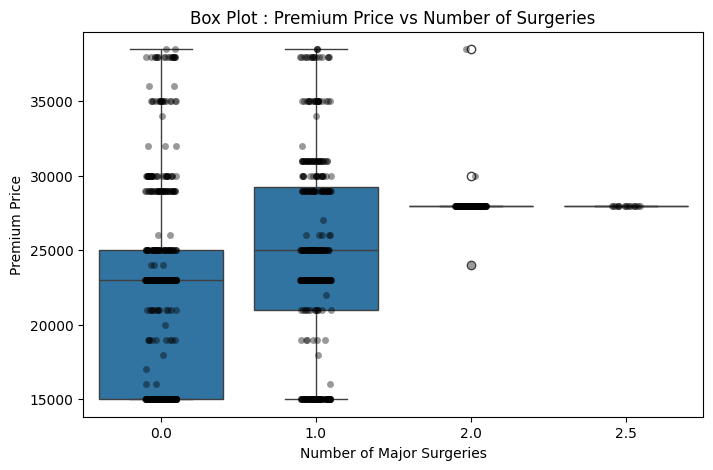

In [32]:
# Box plot creation to verify the kruksal test
df_capped['NumberOfMajorSurgeries'] = df_capped['NumberOfMajorSurgeries'].astype('category')
plt.figure(figsize=(8,5))
sns.boxplot(data=df_capped,x='NumberOfMajorSurgeries',y='PremiumPrice')

plt.xlabel('Number of Major Surgeries')
plt.ylabel('Premium Price')

sns.stripplot(data=df_capped,x='NumberOfMajorSurgeries',
              y='PremiumPrice',color='black',alpha=0.4)

plt.title("Box Plot : Premium Price vs Number of Surgeries")
plt.show()


In [33]:
# H0: Age has no effect on Premium Price
# Ha: Age has effect on Premium Price

hypothesis_test_num(x=df_capped['Age'], y=df_capped['PremiumPrice'], alpha=0.05)

'We will reject h0'

In [34]:
# H0: BMI_Chronic_Interaction has no effect on Premium Price
# Ha: BMI_Chronic_Interaction has effect on Premium Price

hypothesis_test_num(x=df_capped['BMI_Chronic_Interaction'], y=df_capped['PremiumPrice'], alpha=0.05)

'We will reject h0'

In [42]:
list_selected_features = [
    'Age_Health_Interaction',    # Age × Health Risk (replaces Age + Health_Risk_Score)
    'BMI_Chronic_Interaction',   # BMI × Chronic Disease (replaces BMI + AnyChronicDiseases)
    'AnyTransplants',            # Significant in Mann-Whitney test
    'NumberOfMajorSurgeries',    # Significant in Kruskal-Wallis test
]

df_vif = df_capped[list_selected_features].copy()

vif_data = pd.DataFrame()
vif_data['Feature'] = df_vif.columns
vif_data['VIF'] = [variance_inflation_factor(df_vif.values, i) 
                   for i in range(len(df_vif.columns))]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

                   Feature       VIF
0   Age_Health_Interaction  2.721744
3   NumberOfMajorSurgeries  2.137048
1  BMI_Chronic_Interaction  1.343957
2           AnyTransplants  1.088449


C:\Users\dev\AppData\Local\Temp\ipykernel_23052\773848011.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_data, x='VIF', y='Feature', palette='RdYlGn_r')


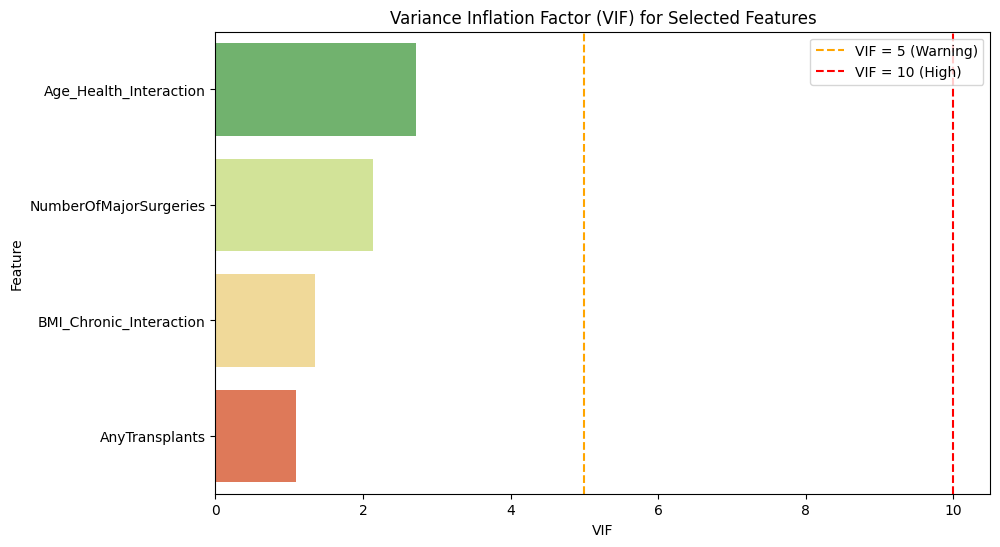

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(data=vif_data, x='VIF', y='Feature', palette='RdYlGn_r')
plt.axvline(x=5, color='orange', linestyle='--', label='VIF = 5 (Warning)')
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10 (High)')
plt.title('Variance Inflation Factor (VIF) for Selected Features')
plt.legend()
plt.show()

In [45]:
# Features from VIF analysis
X = df_capped[list_selected_features]
y = df_capped['PremiumPrice']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Compare all models
models = {
    'Linear Regression'     : LinearRegression(),
    'Random Forest'         : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'     : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    print(f"\n{name}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  R²   : {r2:.4f}")


Linear Regression
  RMSE : 5184.09
  MAE  : 4193.64
  R²   : 0.3698

Random Forest
  RMSE : 4527.40
  MAE  : 3030.53
  R²   : 0.5193

Gradient Boosting
  RMSE : 4737.85
  MAE  : 3376.15
  R²   : 0.4736


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV R²      : 0.6983

Tuned Random Forest
  RMSE : 2753.46
  MAE  : 1932.21
  R²   : 0.8222


C:\Users\dev\AppData\Local\Temp\ipykernel_23052\3442915024.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='viridis')


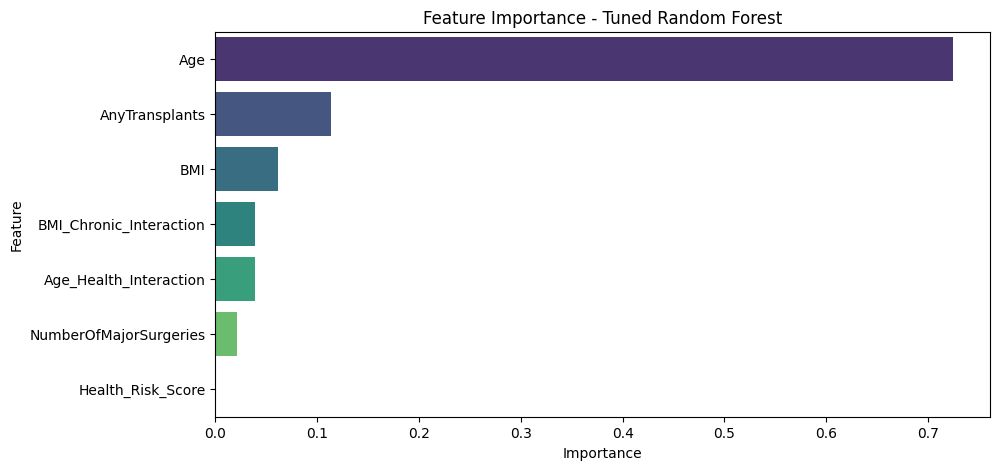

In [ ]:
# Step 1: Expand feature set - add back individual significant features
list_selected_features_v2 = [
    'Age',                       # Direct effect on premium
    'BMI',                       # Direct effect on premium  
    'Health_Risk_Score',         # Overall health risk
    'Age_Health_Interaction',    # Age × Health Risk synergy
    'BMI_Chronic_Interaction',   # BMI × Chronic disease synergy
    'AnyTransplants',            # High risk factor
    'NumberOfMajorSurgeries',    # Significant in Kruskal-Wallis
]

X = df_capped[list_selected_features_v2]
y = df_capped['PremiumPrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 2: Tune Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator  = rf,
    param_grid = param_grid,
    cv         = 5,             # 5-fold cross validation
    scoring    = 'r2',
    n_jobs     = -1,            # Use all CPU cores
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV R²      : {grid_search.best_score_:.4f}")

# Step 3: Evaluate best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"\nTuned Random Forest")
print(f"  RMSE : {rmse:.2f}")
print(f"  MAE  : {mae:.2f}")
print(f"  R²   : {r2:.4f}")

# Step 4: Feature Importance
feat_importance = pd.DataFrame({
    'Feature'   : list_selected_features_v2,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Tuned Random Forest')
plt.show()